In [2]:
import json
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)


In [3]:
with open("data/category_messages.json", "r", encoding="utf-8") as f:
    category_messages = json.load(f)


In [4]:
with open("data/aggregates.json", "r", encoding="utf-8") as f:
    aggregates = json.load(f)


In [5]:
rows = []

for category, messages in category_messages.items():
    for m in messages:
        rows.append({
            "contact_id": m["contact_id"],
            "email": m["email"],
            "category": category,
            "timestamp": m["timestamp"],
            "message": m["message"]
        })

df = pd.DataFrame(rows)
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

df.head()


,contact_id,email,category,timestamp,message
0,rWz4UTtLtUnRPrEhR1aK,hiteshi.jn@gmail.com,Churn Signals,2026-01-30 20:55:53.733000+00:00,Cancel Now
1,VzVsfvhwmljB462IkSEp,siddharth.parimal@gmail.com,Churn Signals,2026-02-01 15:10:38.769000+00:00,Cancel Now
2,5zZFPsaJwx4sXUWuq9pz,batool_135110@yahoo.com,Churn Signals,2026-02-01 19:30:38.591000+00:00,Cancel Now
3,wiKqwcADX0XUhYB1pWWN,catduggal@gmail.com,Churn Signals,2026-01-03 19:49:21.056000+00:00,Cancel Now
4,PwV2sQNOjySbqgQ5PJdx,tasneemchand@gmail.con,Churn Signals,2026-01-05 01:52:05.726000+00:00,Cancel Now


In [6]:
cat_counts = df["category"].value_counts()

cat_counts


category
Class Management       6747
Other                  3793
General Questions      1123
Class Questions         959
Trial Class             724
Plans & Pricing         643
Subscription            555
Churn Signals           447
Billing                 368
Technical Questions     364
Account Management      208
Curriculum              143
Discounts & Offers      118
Referral                 67
Terms of Service          1
Name: count, dtype: int64

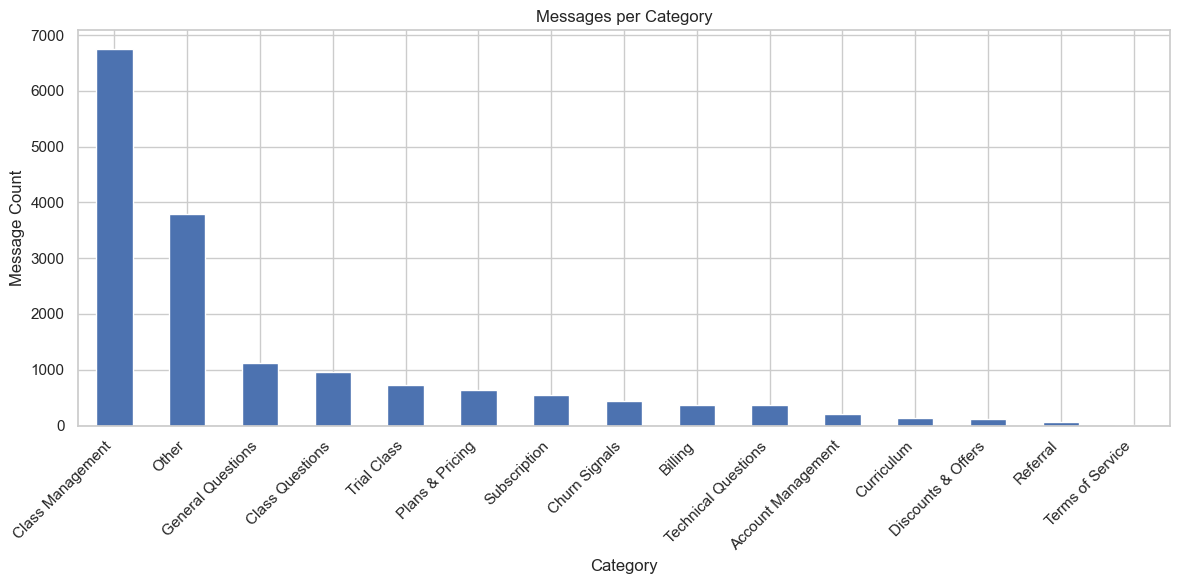

In [7]:
cat_counts.plot(kind="bar")
plt.title("Messages per Category")
plt.xlabel("Category")
plt.ylabel("Message Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [8]:
unique_users = df.groupby("category")["contact_id"].nunique().sort_values(ascending=False)
unique_users


category
Other                  1331
Class Management       1245
General Questions       473
Class Questions         463
Trial Class             415
Plans & Pricing         401
Churn Signals           357
Subscription            306
Technical Questions     237
Billing                 201
Account Management      136
Discounts & Offers       90
Curriculum               90
Referral                 39
Terms of Service          1
Name: contact_id, dtype: int64

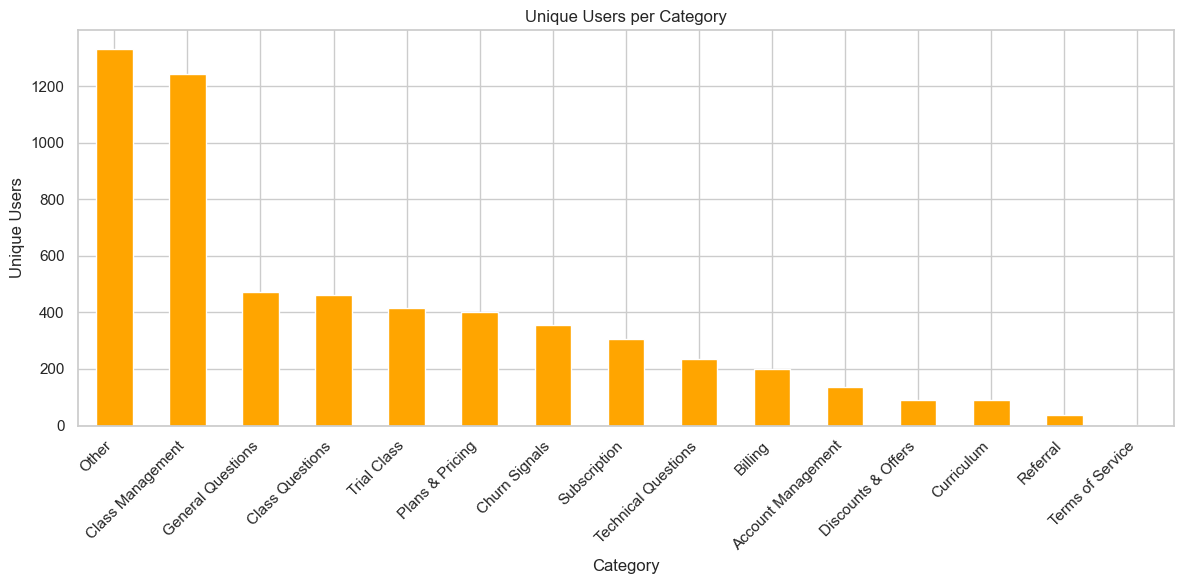

In [9]:
unique_users.plot(kind="bar", color="orange")
plt.title("Unique Users per Category")
plt.xlabel("Category")
plt.ylabel("Unique Users")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


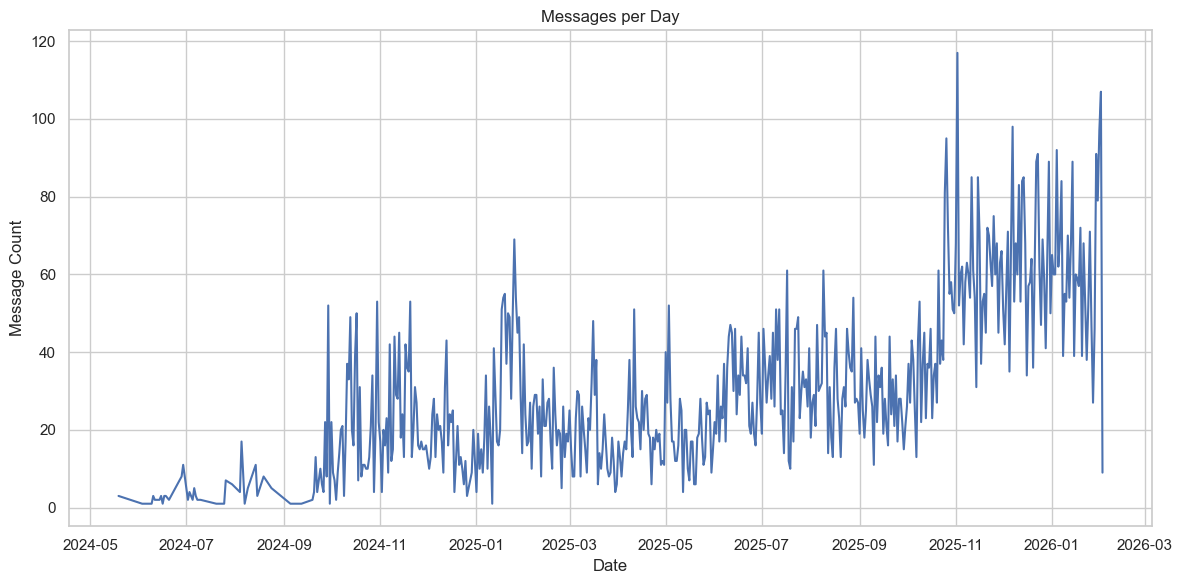

In [10]:
df["date"] = df["timestamp"].dt.date

daily_msgs = df.groupby("date").size()

daily_msgs.plot()
plt.title("Messages per Day")
plt.xlabel("Date")
plt.ylabel("Message Count")
plt.tight_layout()
plt.show()


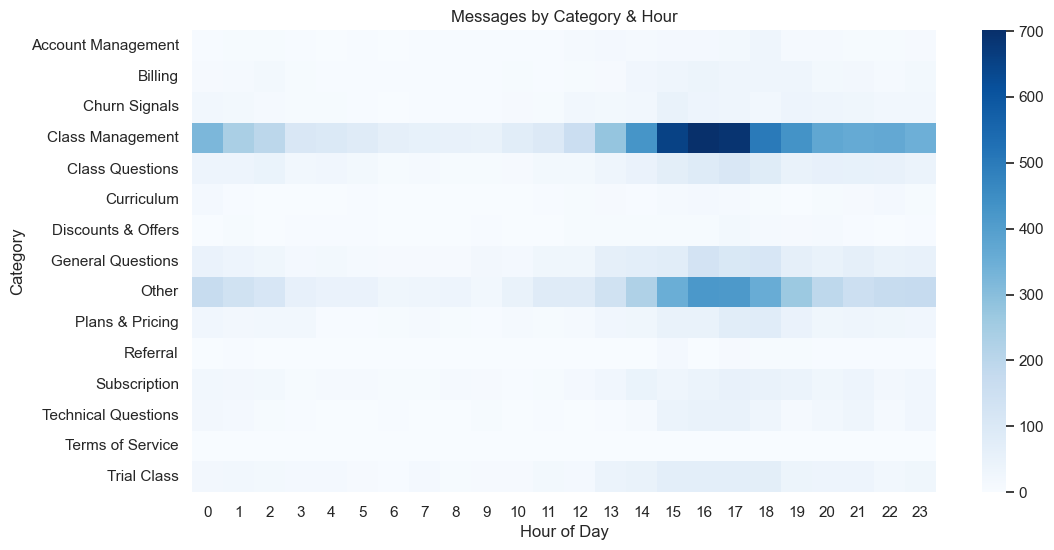

In [11]:
df["hour"] = df["timestamp"].dt.hour

heatmap_data = df.pivot_table(
    index="category",
    columns="hour",
    values="message",
    aggfunc="count",
    fill_value=0
)

sns.heatmap(heatmap_data, cmap="Blues")
plt.title("Messages by Category & Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Category")
plt.show()


In [12]:
funnel = [
    "General Questions",
    "Plans & Pricing",
    "Trial Class",
    "Subscription"
]


In [13]:
funnel_counts = []

for step in funnel:
    users = df[df["category"] == step]["contact_id"].nunique()
    funnel_counts.append(users)

funnel_df = pd.DataFrame({
    "stage": funnel,
    "users": funnel_counts
})

funnel_df


,stage,users
0,General Questions,473
1,Plans & Pricing,401
2,Trial Class,415
3,Subscription,306


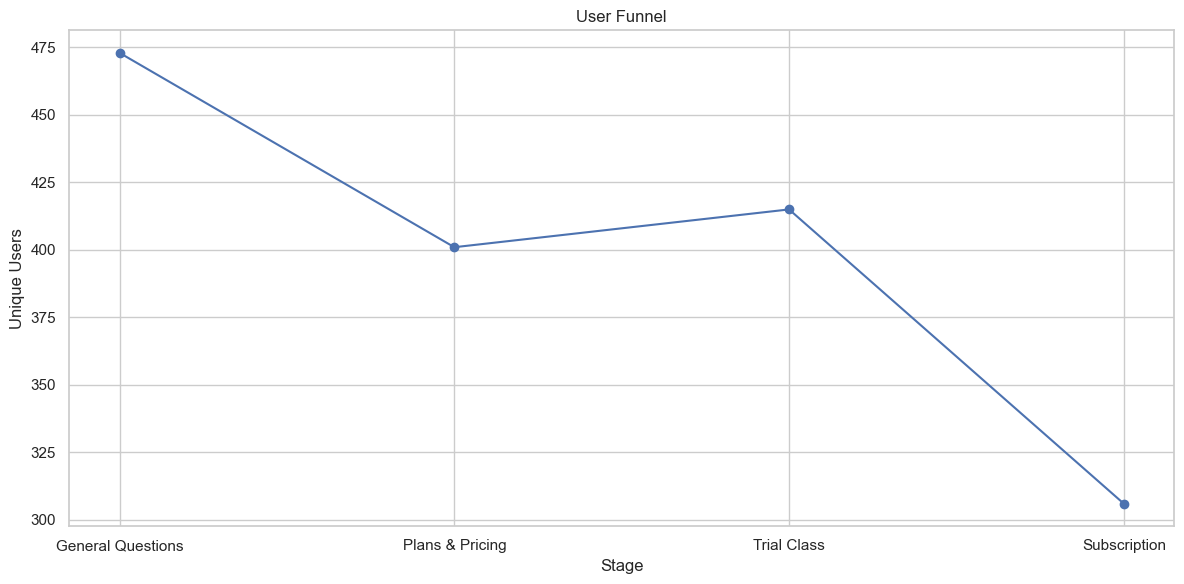

In [14]:
plt.plot(funnel_df["stage"], funnel_df["users"], marker="o")
plt.title("User Funnel")
plt.xlabel("Stage")
plt.ylabel("Unique Users")
plt.tight_layout()
plt.show()


In [15]:
churn_users = (
    df[df["category"] == "Churn Signals"]
    .groupby("contact_id")
    .size()
    .sort_values(ascending=False)
)

churn_users.head(10)


contact_id
O1hN04H3ZRTfqomLW8C4    6
RU0SRfvutCvSy8XQumPZ    5
bff3rilGjNHhjN4PdWPr    4
l4yz0kyzuM6teOgnUhXc    4
1hkpT7N1foPExaP5bMCo    4
OLZd7ukIc4OpuZO5wYJR    4
yrtBqCGGh3FRP4gz8LuW    4
M0lju2sjRUGhYtdTwi3v    4
Oj7bJozfUiSfD5STLYZo    3
JG1pJHypzYOHS5CZwFu7    3
dtype: int64

In [16]:
high_intent_users = df[
    df["category"].isin(["Plans & Pricing", "Trial Class"])
].groupby("contact_id")["category"].nunique()

high_intent_users[high_intent_users >= 2].sort_values(ascending=False)


contact_id
0jpXTPunFhOKta4DmXsp    2
0ncdzyl4nG31TtWPkfYd    2
2y7fGoVL9hMlxvTKWBR4    2
3DLeKeXGZ3ZN29pMiAvt    2
3Fjwknx6kW1gR7sSxJMz    2
                       ..
wevtzLgtlqLAuFRubRK1    2
wi1tJko8nRlTVgzUfUR5    2
yz1HuyxWxJag87COlJj8    2
zEIRJnvs5k81qTdeL0Dj    2
zQlks86OmIIGi7OrNlAa    2
Name: category, Length: 93, dtype: int64

In [17]:
high_intent_users = df[
    df["category"].isin(["Plans & Pricing", "Trial Class"])
].groupby("contact_id")["category"].nunique()

high_intent_users[high_intent_users >= 2].sort_values(ascending=False)


contact_id
0jpXTPunFhOKta4DmXsp    2
0ncdzyl4nG31TtWPkfYd    2
2y7fGoVL9hMlxvTKWBR4    2
3DLeKeXGZ3ZN29pMiAvt    2
3Fjwknx6kW1gR7sSxJMz    2
                       ..
wevtzLgtlqLAuFRubRK1    2
wi1tJko8nRlTVgzUfUR5    2
yz1HuyxWxJag87COlJj8    2
zEIRJnvs5k81qTdeL0Dj    2
zQlks86OmIIGi7OrNlAa    2
Name: category, Length: 93, dtype: int64